# Exploratory Data Analysis (EDA)

This notebook performs a detailed Exploratory Data Analysis (EDA) on two datasets:
1. **ModCloth Dataset** (`modcloth_final_data.json`)
2. **RentTheRunway Dataset** (`renttherunway_final_data.json`)

We will analyze these datasets separately, focusing on data cleaning, transformation, and visualization to understand the distributions, relationships, and potential issues within the data.

## 1. Setup and Data Loading

test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load datasets
modcloth_df = pd.read_json('Data/modcloth_final_data.json', lines=True)
rtr_df = pd.read_json('Data/renttherunway_final_data.json', lines=True)

print(f"ModCloth Dataset Shape: {modcloth_df.shape}")
print(f"RentTheRunway Dataset Shape: {rtr_df.shape}")

ModCloth Dataset Shape: (82790, 18)
RentTheRunway Dataset Shape: (192544, 15)


## 2. ModCloth Dataset Analysis

### 2.1 Data Cleaning and Transformation

The ModCloth dataset contains several columns that need cleaning:
- **Height**: Formatted as "Xft Yin". Needs to be converted to total inches.
- **Numeric Columns**: Columns like `waist`, `hips`, `bra size`, `bust`, and `shoe size` are stored as strings and need to be converted to numeric types.
- **Missing Values**: We will identify the extent of missing data.

In [2]:
# Display initial info and missing values
print("ModCloth Dataset Info:")
modcloth_df.info()

print("\nMissing Values in ModCloth Dataset:")
print(modcloth_df.isnull().sum())

# Display first few rows
modcloth_df.head()

ModCloth Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82790 entries, 0 to 82789
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         82790 non-null  int64  
 1   waist           2882 non-null   float64
 2   size            82790 non-null  int64  
 3   quality         82722 non-null  float64
 4   cup size        76535 non-null  object 
 5   hips            56064 non-null  float64
 6   bra size        76772 non-null  float64
 7   category        82790 non-null  object 
 8   bust            11854 non-null  object 
 9   height          81683 non-null  object 
 10  user_name       82790 non-null  object 
 11  length          82755 non-null  object 
 12  fit             82790 non-null  object 
 13  user_id         82790 non-null  int64  
 14  shoe size       27915 non-null  float64
 15  shoe width      18607 non-null  object 
 16  review_summary  76065 non-null  object 
 17  review_t

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


In [3]:
# Function to convert height from "Xft Yin" to inches
def convert_height_to_inches(height_str):
    if pd.isna(height_str):
        return np.nan
    try:
        parts = height_str.split('ft')
        feet = int(parts[0].strip())
        inches = 0
        if len(parts) > 1 and 'in' in parts[1]:
            inches = int(parts[1].replace('in', '').strip())
        return (feet * 12) + inches
    except:
        return np.nan

# Apply height conversion
modcloth_df['height_inches'] = modcloth_df['height'].apply(convert_height_to_inches)

# Convert 'bust' to numeric, coercing errors to NaN (some might be strings like '34d')
# We will extract just the numeric part for 'bust' if it contains letters
modcloth_df['bust'] = modcloth_df['bust'].str.extract('(\d+)').astype(float)

# Ensure other numeric columns are float
numeric_cols = ['waist', 'hips', 'bra size', 'shoe size', 'quality']
for col in numeric_cols:
    modcloth_df[col] = pd.to_numeric(modcloth_df[col], errors='coerce')

# Check the cleaned data
modcloth_df[['height', 'height_inches', 'bust', 'waist', 'hips', 'bra size', 'shoe size']].head()

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
C:\Users\anany\AppData\Local\Temp\ipykernel_33332\848869502.py:20: SyntaxWarning: invalid escape sequence '\d'
  modcloth_df['bust'] = modcloth_df['bust'].str.extract('(\d+)').astype(float)


,height,height_inches,bust,waist,hips,bra size,shoe size
0,5ft 6in,66.0,36.0,29.0,38.0,34.0,NaN
1,5ft 2in,62.0,NaN,31.0,30.0,36.0,NaN
2,5ft 7in,67.0,NaN,30.0,NaN,32.0,9.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5ft 2in,62.0,NaN,NaN,NaN,36.0,NaN


### 2.2 Univariate Analysis (ModCloth)

Let's look at the distributions of the numerical features and the frequencies of categorical features.

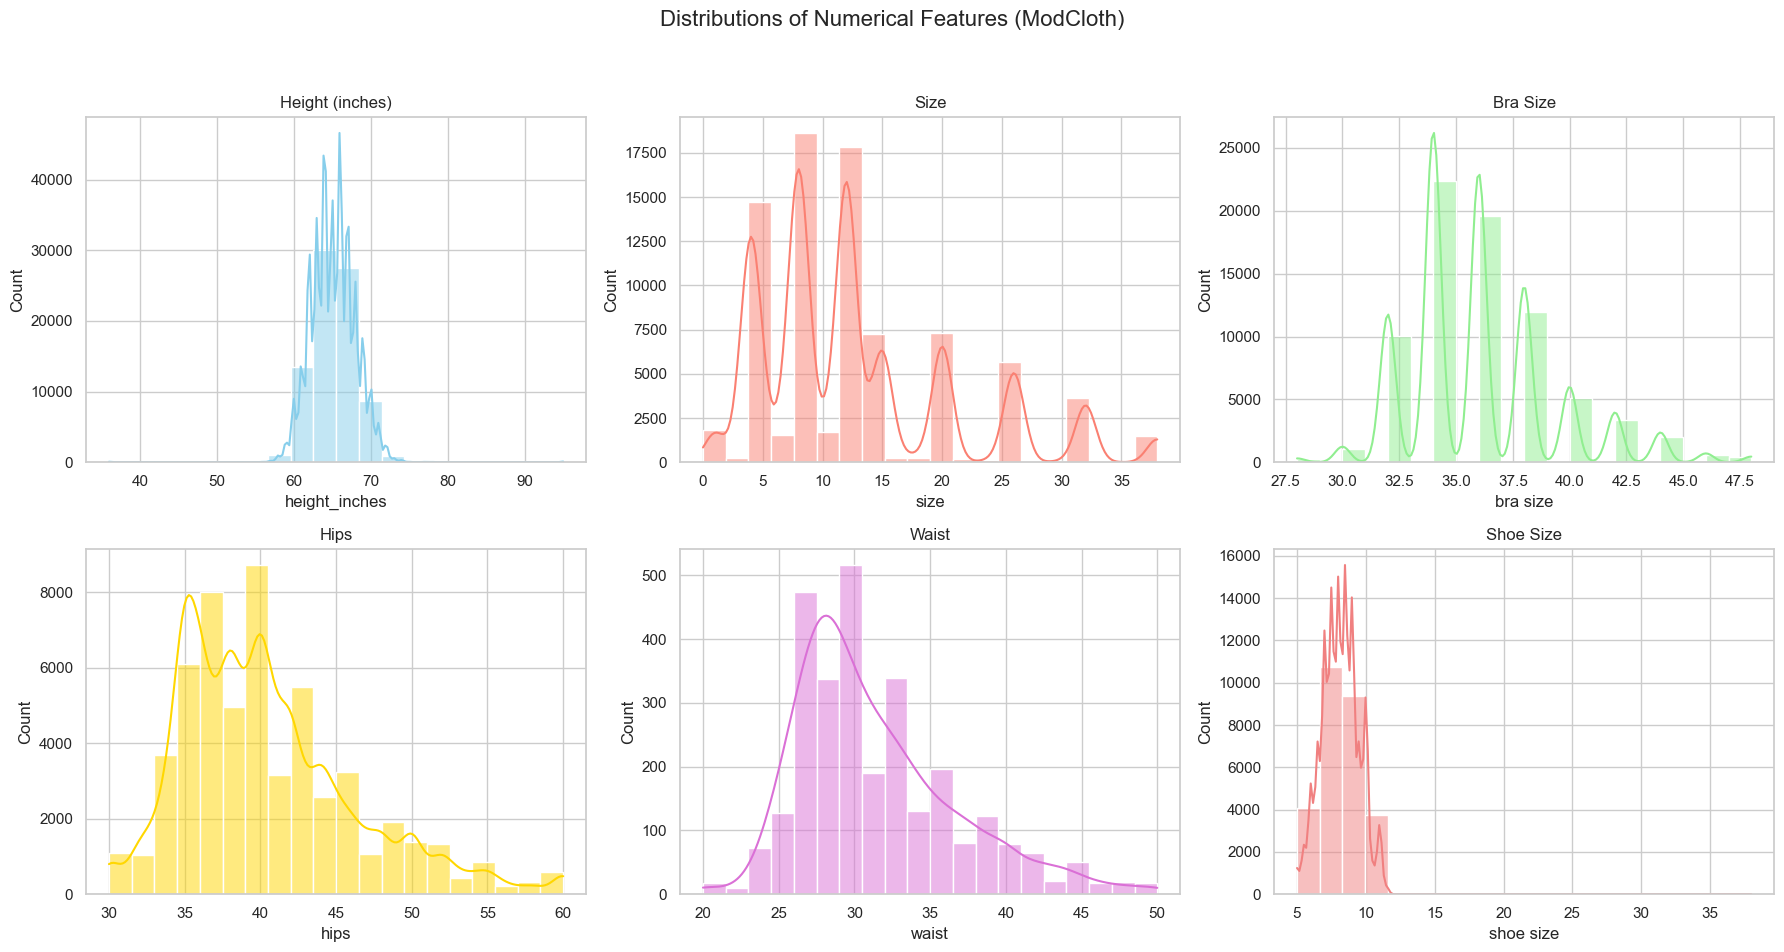

In [4]:
# Plot distributions of numerical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions of Numerical Features (ModCloth)', fontsize=16)

sns.histplot(modcloth_df['height_inches'].dropna(), bins=20, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Height (inches)')

sns.histplot(modcloth_df['size'].dropna(), bins=20, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Size')

sns.histplot(modcloth_df['bra size'].dropna(), bins=20, kde=True, ax=axes[0, 2], color='lightgreen')
axes[0, 2].set_title('Bra Size')

sns.histplot(modcloth_df['hips'].dropna(), bins=20, kde=True, ax=axes[1, 0], color='gold')
axes[1, 0].set_title('Hips')

sns.histplot(modcloth_df['waist'].dropna(), bins=20, kde=True, ax=axes[1, 1], color='orchid')
axes[1, 1].set_title('Waist')

sns.histplot(modcloth_df['shoe size'].dropna(), bins=20, kde=True, ax=axes[1, 2], color='lightcoral')
axes[1, 2].set_title('Shoe Size')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\anany\AppData\Local\Temp\ipykernel_33332\3005897727.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=modcloth_df, x='fit', ax=axes[0, 0], palette='Set2', order=['small', 'fit', 'large'])
C:\Users\anany\AppData\Local\Temp\ipykernel_33332\3005897727.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=modcloth_df, y='category', ax=axes[0, 1], palette='Set3', order=modcloth_df['category'].value_counts().index)
C:\Users\anany\AppData\Local\Temp\ipykernel_33332\3005897727.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.count

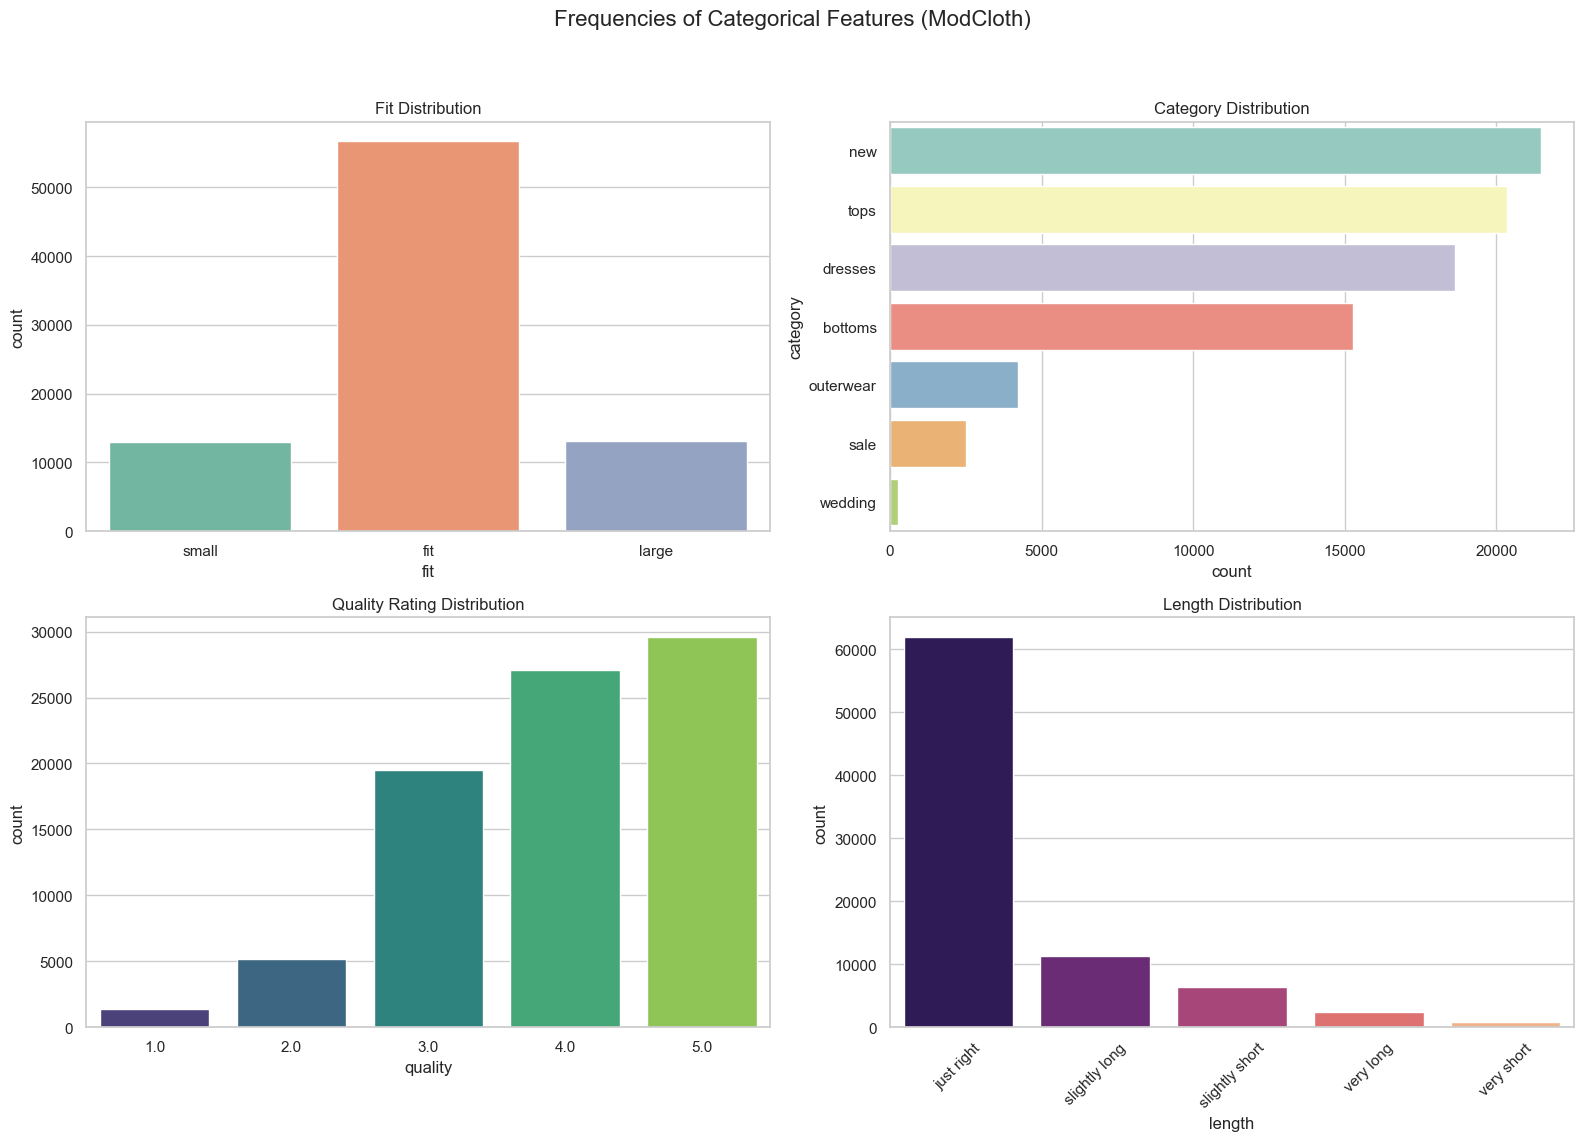

In [5]:
# Plot frequencies of categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Frequencies of Categorical Features (ModCloth)', fontsize=16)

sns.countplot(data=modcloth_df, x='fit', ax=axes[0, 0], palette='Set2', order=['small', 'fit', 'large'])
axes[0, 0].set_title('Fit Distribution')

sns.countplot(data=modcloth_df, y='category', ax=axes[0, 1], palette='Set3', order=modcloth_df['category'].value_counts().index)
axes[0, 1].set_title('Category Distribution')

sns.countplot(data=modcloth_df, x='quality', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Quality Rating Distribution')

sns.countplot(data=modcloth_df, x='length', ax=axes[1, 1], palette='magma', order=modcloth_df['length'].value_counts().index)
axes[1, 1].set_title('Length Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 2.3 Bivariate Analysis (ModCloth)

Let's explore how different features relate to the target variable `fit`.

C:\Users\anany\AppData\Local\Temp\ipykernel_33332\3552573351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=modcloth_df, x='fit', y='height_inches', ax=axes[0], order=['small', 'fit', 'large'], palette='Set2')
C:\Users\anany\AppData\Local\Temp\ipykernel_33332\3552573351.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=modcloth_df, x='fit', y='size', ax=axes[1], order=['small', 'fit', 'large'], palette='Set2')
C:\Users\anany\AppData\Local\Temp\ipykernel_33332\3552573351.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(da

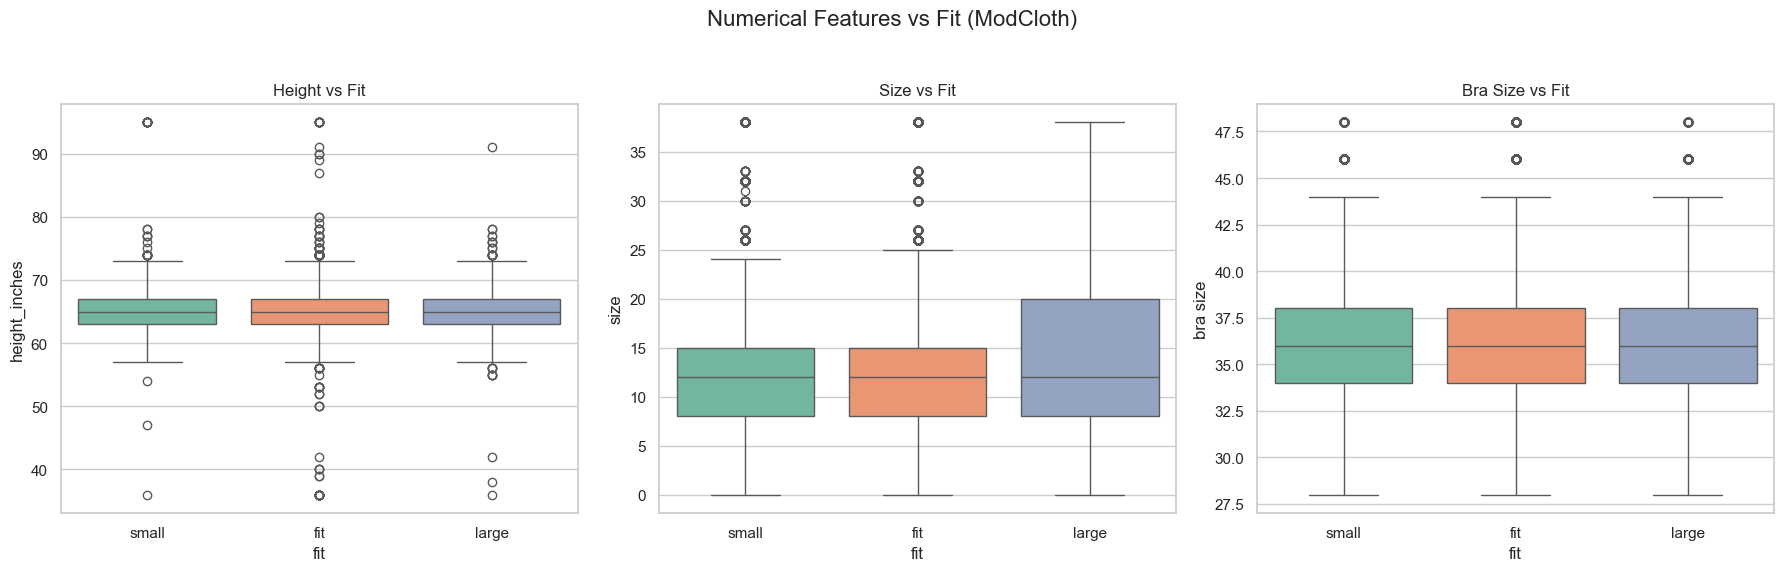

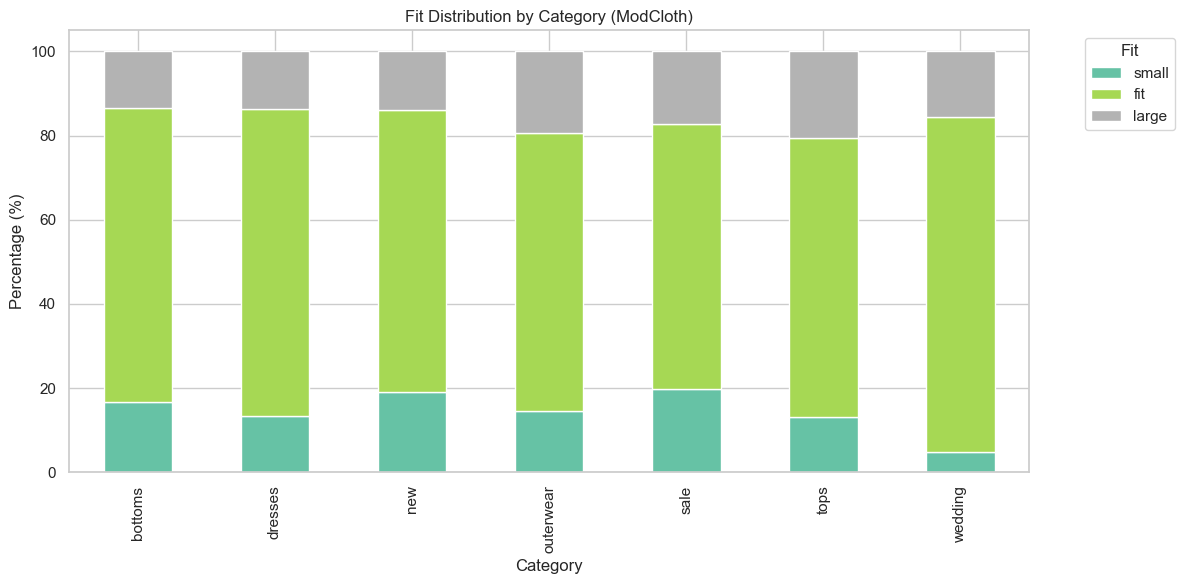

In [6]:
# Boxplots for numerical features vs fit
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Numerical Features vs Fit (ModCloth)', fontsize=16)

sns.boxplot(data=modcloth_df, x='fit', y='height_inches', ax=axes[0], order=['small', 'fit', 'large'], palette='Set2')
axes[0].set_title('Height vs Fit')

sns.boxplot(data=modcloth_df, x='fit', y='size', ax=axes[1], order=['small', 'fit', 'large'], palette='Set2')
axes[1].set_title('Size vs Fit')

sns.boxplot(data=modcloth_df, x='fit', y='bra size', ax=axes[2], order=['small', 'fit', 'large'], palette='Set2')
axes[2].set_title('Bra Size vs Fit')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Stacked bar chart for Category vs Fit
category_fit = pd.crosstab(modcloth_df['category'], modcloth_df['fit'], normalize='index') * 100
category_fit = category_fit[['small', 'fit', 'large']] # Reorder columns
category_fit.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Fit Distribution by Category (ModCloth)')
plt.ylabel('Percentage (%)')
plt.xlabel('Category')
plt.legend(title='Fit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. RentTheRunway Dataset Analysis

### 3.1 Data Cleaning and Transformation

The RentTheRunway dataset also requires cleaning:
- **Height**: Formatted as "X' Y\"". Needs to be converted to total inches.
- **Weight**: Contains "lbs" suffix. Needs to be stripped and converted to numeric.
- **Bust Size**: Combines band size and cup size (e.g., "34d"). We will split this into `bra_size` and `cup_size`.
- **Review Date**: Needs to be parsed into datetime objects.
- **Numeric Columns**: `age`, `rating`, and `size` need to be numeric.

In [7]:
# Display initial info and missing values
print("RentTheRunway Dataset Info:")
rtr_df.info()

print("\nMissing Values in RentTheRunway Dataset:")
print(rtr_df.isnull().sum())

# Display first few rows
rtr_df.head()

RentTheRunway Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192544 entries, 0 to 192543
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   fit             192544 non-null  object 
 1   user_id         192544 non-null  int64  
 2   bust size       174133 non-null  object 
 3   item_id         192544 non-null  int64  
 4   weight          162562 non-null  object 
 5   rating          192462 non-null  float64
 6   rented for      192534 non-null  object 
 7   review_text     192544 non-null  object 
 8   body type       177907 non-null  object 
 9   review_summary  192544 non-null  object 
 10  category        192544 non-null  object 
 11  height          191867 non-null  object 
 12  size            192544 non-null  int64  
 13  age             191584 non-null  float64
 14  review_date     192544 non-null  object 
dtypes: float64(2), int64(3), object(10)
memory usage: 22.0+ MB

Missing Values

,fit,user_id,bust size,item_id,weight,rating,rented for,review_text,body type,review_summary,category,height,size,age,review_date
0,fit,420272,34d,2260466,137lbs,10.0,vacation,An adorable romper! Belt and zipper were a lit...,hourglass,So many compliments!,romper,"5' 8""",14,28.0,"April 20, 2016"
1,fit,273551,34b,153475,132lbs,10.0,other,I rented this dress for a photo shoot. The the...,straight & narrow,I felt so glamourous!!!,gown,"5' 6""",12,36.0,"June 18, 2013"
2,fit,360448,NaN,1063761,NaN,10.0,party,This hugged in all the right places! It was a ...,NaN,It was a great time to celebrate the (almost) ...,sheath,"5' 4""",4,116.0,"December 14, 2015"
3,fit,909926,34c,126335,135lbs,8.0,formal affair,I rented this for my company's black tie award...,pear,Dress arrived on time and in perfect condition.,dress,"5' 5""",8,34.0,"February 12, 2014"
4,fit,151944,34b,616682,145lbs,10.0,wedding,I have always been petite in my upper body and...,athletic,Was in love with this dress !!!,gown,"5' 9""",12,27.0,"September 26, 2016"


In [8]:
import re

# Function to convert RTR height format "X' Y"" to inches
def convert_rtr_height(height_str):
    if pd.isna(height_str):
        return np.nan
    try:
        match = re.match(r"(\d+)'\s*(\d*)", str(height_str))
        if match:
            feet = int(match.group(1))
            inches = int(match.group(2)) if match.group(2) else 0
            return feet * 12 + inches
        return np.nan
    except:
        return np.nan

# Apply conversions
rtr_df['height_inches'] = rtr_df['height'].apply(convert_rtr_height)
rtr_df['weight_lbs'] = rtr_df['weight'].str.replace('lbs', '', regex=False).str.strip()
rtr_df['weight_lbs'] = pd.to_numeric(rtr_df['weight_lbs'], errors='coerce')

# Split bust size into bra_size (numeric) and cup_size (alpha)
rtr_df['bra_size'] = rtr_df['bust size'].str.extract(r'(\d+)').astype(float)
rtr_df['cup_size'] = rtr_df['bust size'].str.extract(r'(\d+)([a-zA-Z+]+)$')[1]

# Parse review_date
rtr_df['review_date'] = pd.to_datetime(rtr_df['review_date'], format='%B %d, %Y', errors='coerce')

# Convert age to numeric and filter extreme outliers
rtr_df['age'] = pd.to_numeric(rtr_df['age'], errors='coerce')
rtr_df.loc[rtr_df['age'] > 90, 'age'] = np.nan  # Remove implausible ages

# Verify the cleaning
print("After Cleaning - Sample Check:")
rtr_df[['height', 'height_inches', 'weight', 'weight_lbs', 'bust size', 'bra_size', 'cup_size', 'review_date', 'age']].head()

After Cleaning - Sample Check:


,height,height_inches,weight,weight_lbs,bust size,bra_size,cup_size,review_date,age
0,"5' 8""",68.0,137lbs,137.0,34d,34.0,d,2016-04-20,28.0
1,"5' 6""",66.0,132lbs,132.0,34b,34.0,b,2013-06-18,36.0
2,"5' 4""",64.0,NaN,NaN,NaN,NaN,NaN,2015-12-14,NaN
3,"5' 5""",65.0,135lbs,135.0,34c,34.0,c,2014-02-12,34.0
4,"5' 9""",69.0,145lbs,145.0,34b,34.0,b,2016-09-26,27.0


### 3.2 Missing Values Visualization

C:\Users\anany\AppData\Local\Temp\ipykernel_33332\3409691804.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mc_missing.values, y=mc_missing.index, ax=axes[0], palette='rocket')
C:\Users\anany\AppData\Local\Temp\ipykernel_33332\3409691804.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rtr_missing.values, y=rtr_missing.index, ax=axes[1], palette='mako')


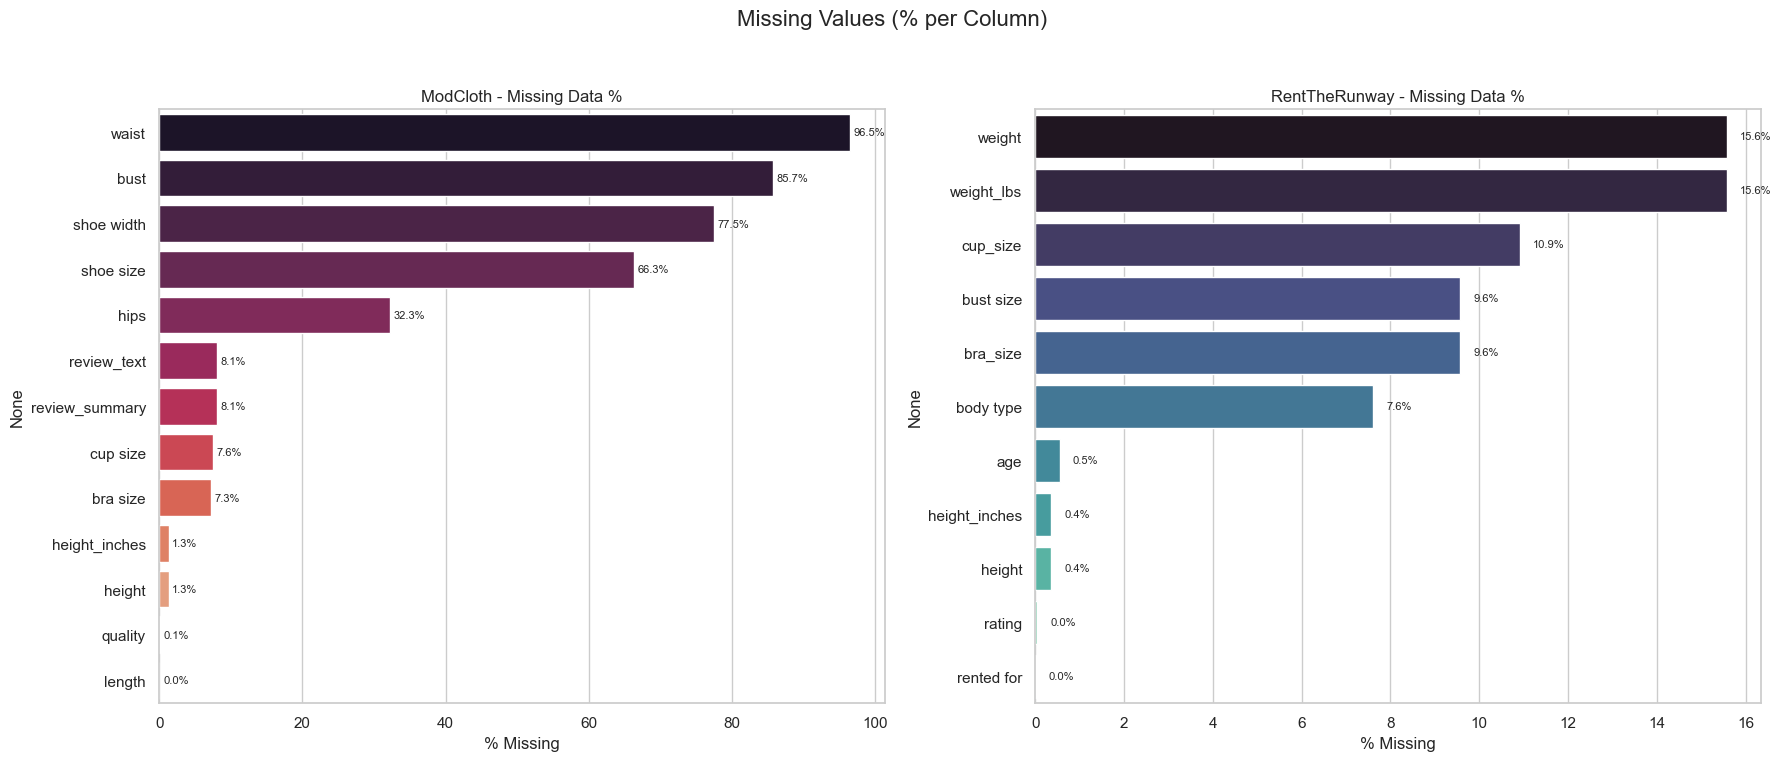

In [9]:
# Missing values heatmap comparison for both datasets
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Missing Values (% per Column)', fontsize=16)

mc_missing = (modcloth_df.isnull().sum() / len(modcloth_df) * 100).sort_values(ascending=False)
mc_missing = mc_missing[mc_missing > 0]
sns.barplot(x=mc_missing.values, y=mc_missing.index, ax=axes[0], palette='rocket')
axes[0].set_title('ModCloth - Missing Data %')
axes[0].set_xlabel('% Missing')
for i, v in enumerate(mc_missing.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

rtr_missing = (rtr_df.isnull().sum() / len(rtr_df) * 100).sort_values(ascending=False)
rtr_missing = rtr_missing[rtr_missing > 0]
sns.barplot(x=rtr_missing.values, y=rtr_missing.index, ax=axes[1], palette='mako')
axes[1].set_title('RentTheRunway - Missing Data %')
axes[1].set_xlabel('% Missing')
for i, v in enumerate(rtr_missing.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 3.3 Univariate Analysis (RentTheRunway)

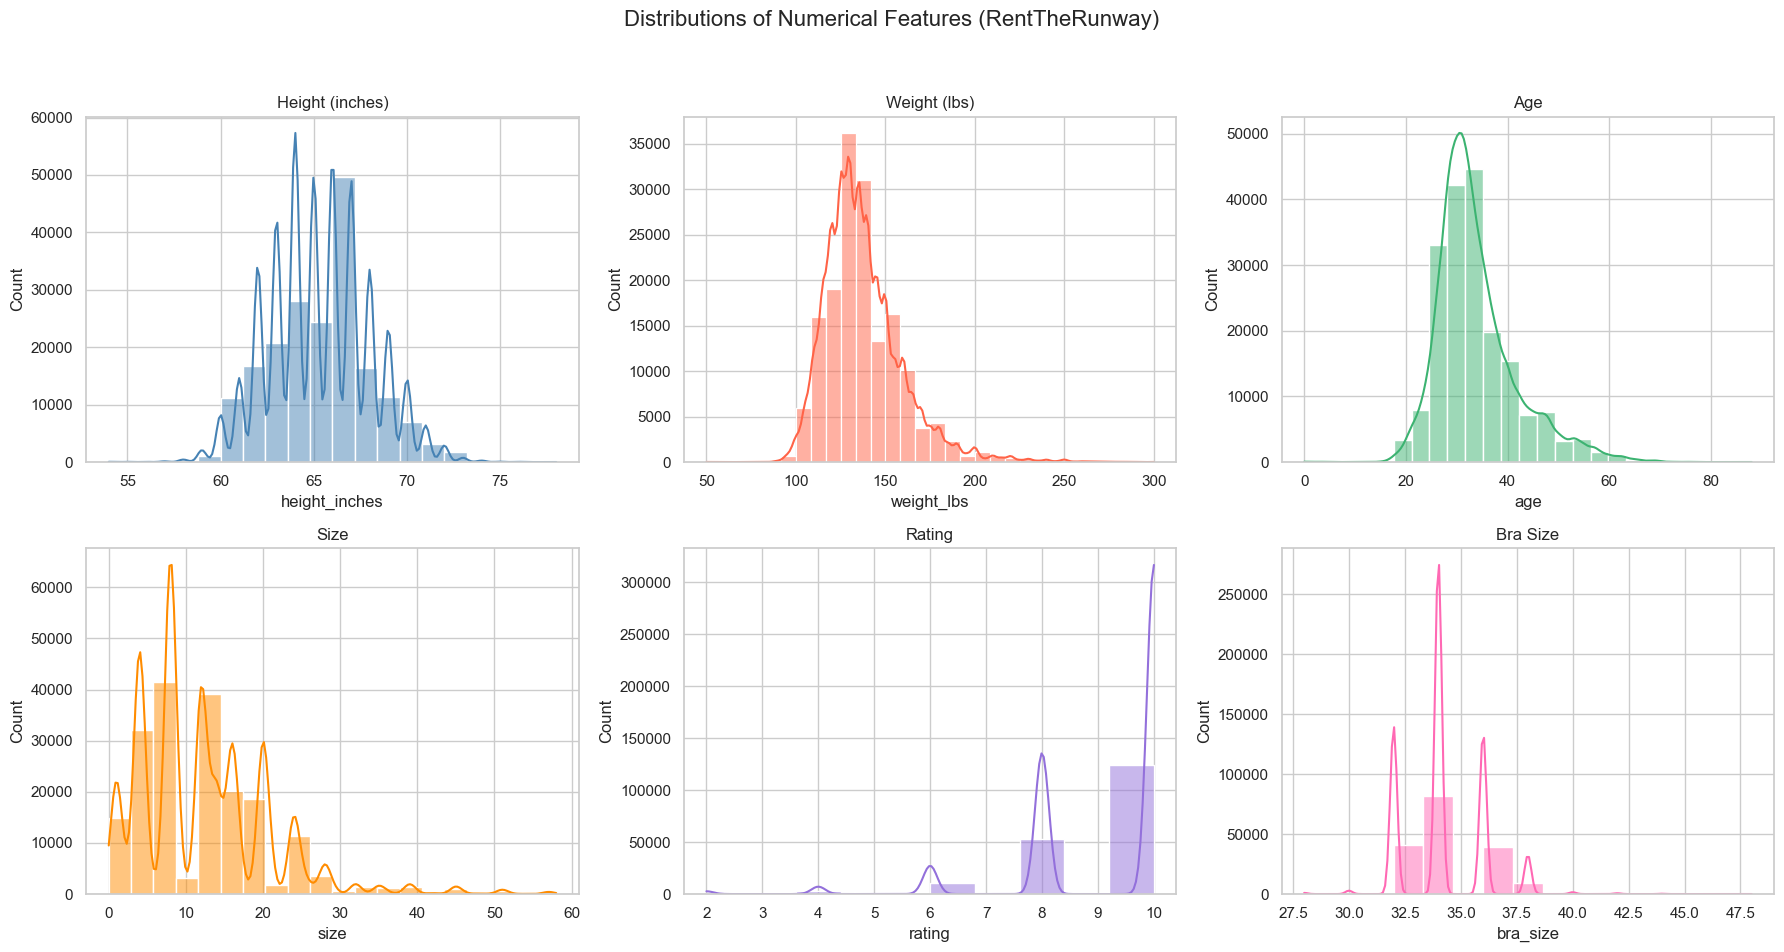

In [10]:
# Plot distributions of numerical features (RTR)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions of Numerical Features (RentTheRunway)', fontsize=16)

sns.histplot(rtr_df['height_inches'].dropna(), bins=20, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Height (inches)')

sns.histplot(rtr_df['weight_lbs'].dropna(), bins=30, kde=True, ax=axes[0, 1], color='tomato')
axes[0, 1].set_title('Weight (lbs)')

sns.histplot(rtr_df['age'].dropna(), bins=25, kde=True, ax=axes[0, 2], color='mediumseagreen')
axes[0, 2].set_title('Age')

sns.histplot(rtr_df['size'].dropna(), bins=20, kde=True, ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Size')

sns.histplot(rtr_df['rating'].dropna(), bins=10, kde=True, ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Rating')

sns.histplot(rtr_df['bra_size'].dropna(), bins=15, kde=True, ax=axes[1, 2], color='hotpink')
axes[1, 2].set_title('Bra Size')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

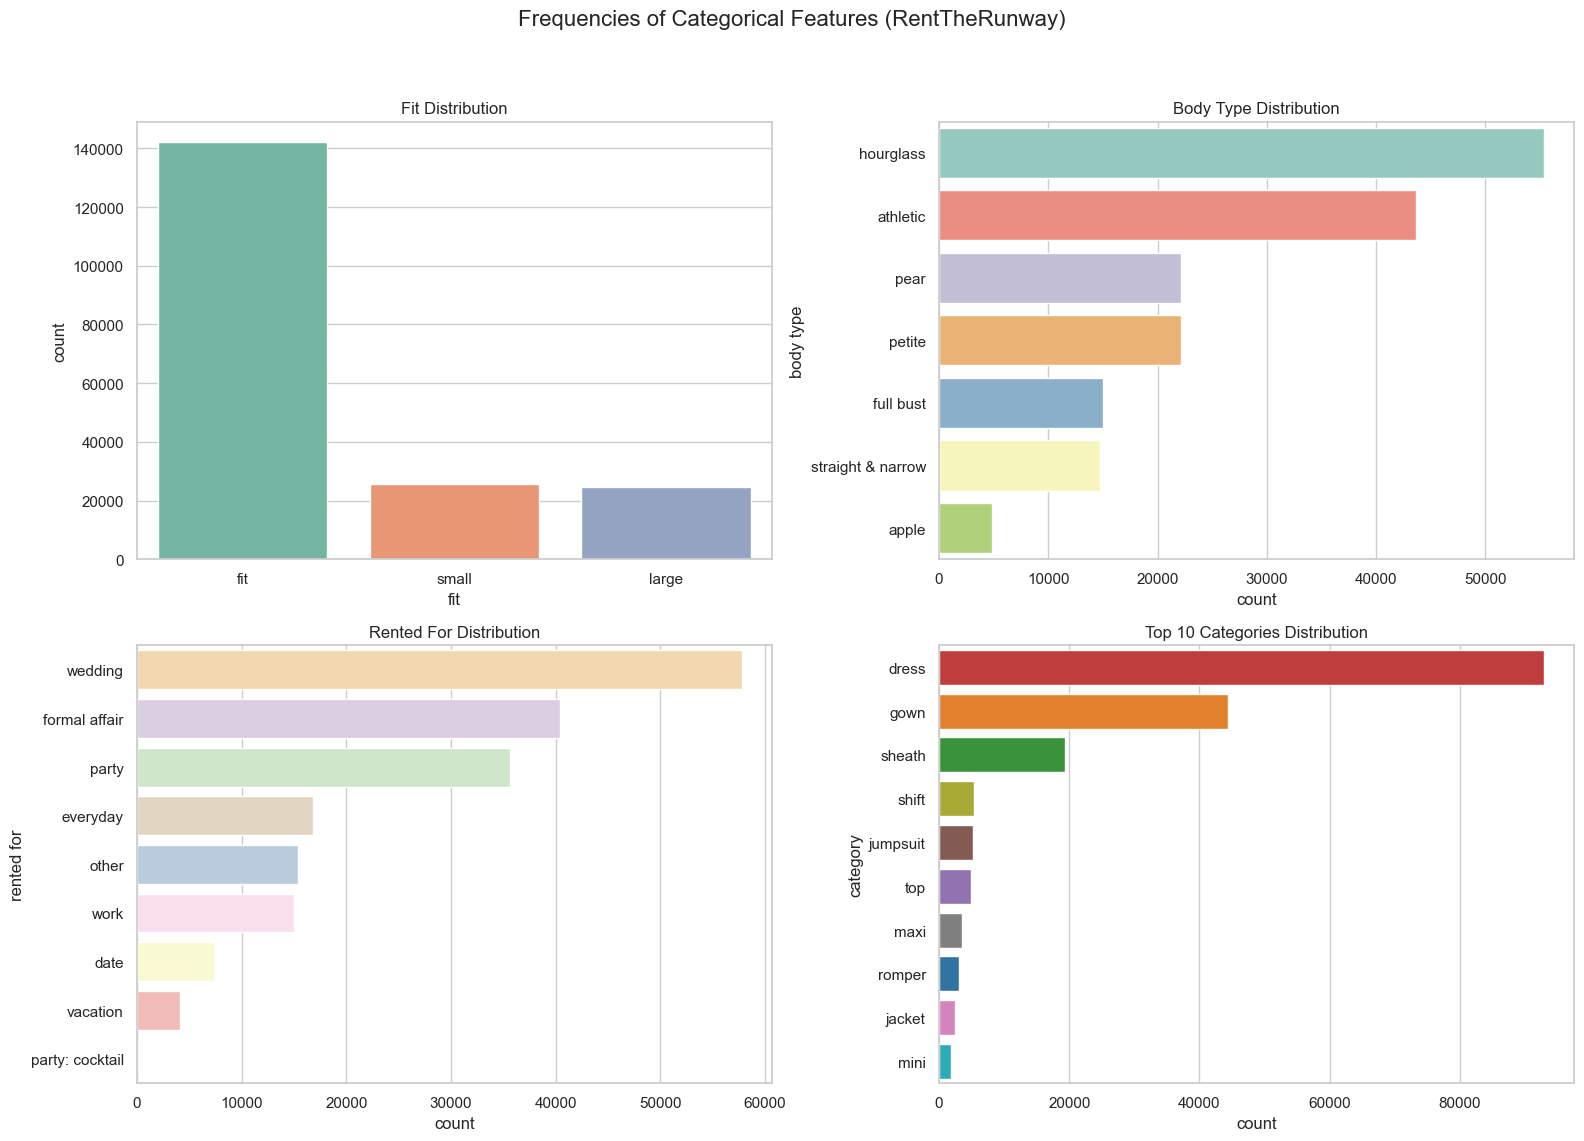

In [11]:
# Plot categorical features (RTR)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Frequencies of Categorical Features (RentTheRunway)', fontsize=16)

# Fit
fit_order = rtr_df['fit'].value_counts().index
sns.countplot(data=rtr_df, x='fit', ax=axes[0, 0], order=fit_order, hue='fit', legend=False, palette='Set2')
axes[0, 0].set_title('Fit Distribution')

# Body Type
body_order = rtr_df['body type'].value_counts().index
sns.countplot(data=rtr_df, y='body type', ax=axes[0, 1], order=body_order, hue='body type', legend=False, palette='Set3')
axes[0, 1].set_title('Body Type Distribution')

# Rented For
rented_order = rtr_df['rented for'].value_counts().index
sns.countplot(data=rtr_df, y='rented for', ax=axes[1, 0], order=rented_order, hue='rented for', legend=False, palette='Pastel1')
axes[1, 0].set_title('Rented For Distribution')

# Category
cat_order = rtr_df['category'].value_counts().nlargest(10).index
sns.countplot(data=rtr_df[rtr_df['category'].isin(cat_order)], y='category', ax=axes[1, 1], order=cat_order, hue='category', legend=False, palette='tab10')
axes[1, 1].set_title('Top 10 Categories Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 3.4 Bivariate Analysis (RentTheRunway)

C:\Users\anany\AppData\Local\Temp\ipykernel_33332\18303340.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=rtr_df, x='fit', y=col, order=fit_order, palette=palette,
C:\Users\anany\AppData\Local\Temp\ipykernel_33332\18303340.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=rtr_df, x='fit', y=col, order=fit_order, palette=palette,
C:\Users\anany\AppData\Local\Temp\ipykernel_33332\18303340.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=rtr_df, x='fit', y=col, order=fit_order, palette=palette,
C:\Users\anan

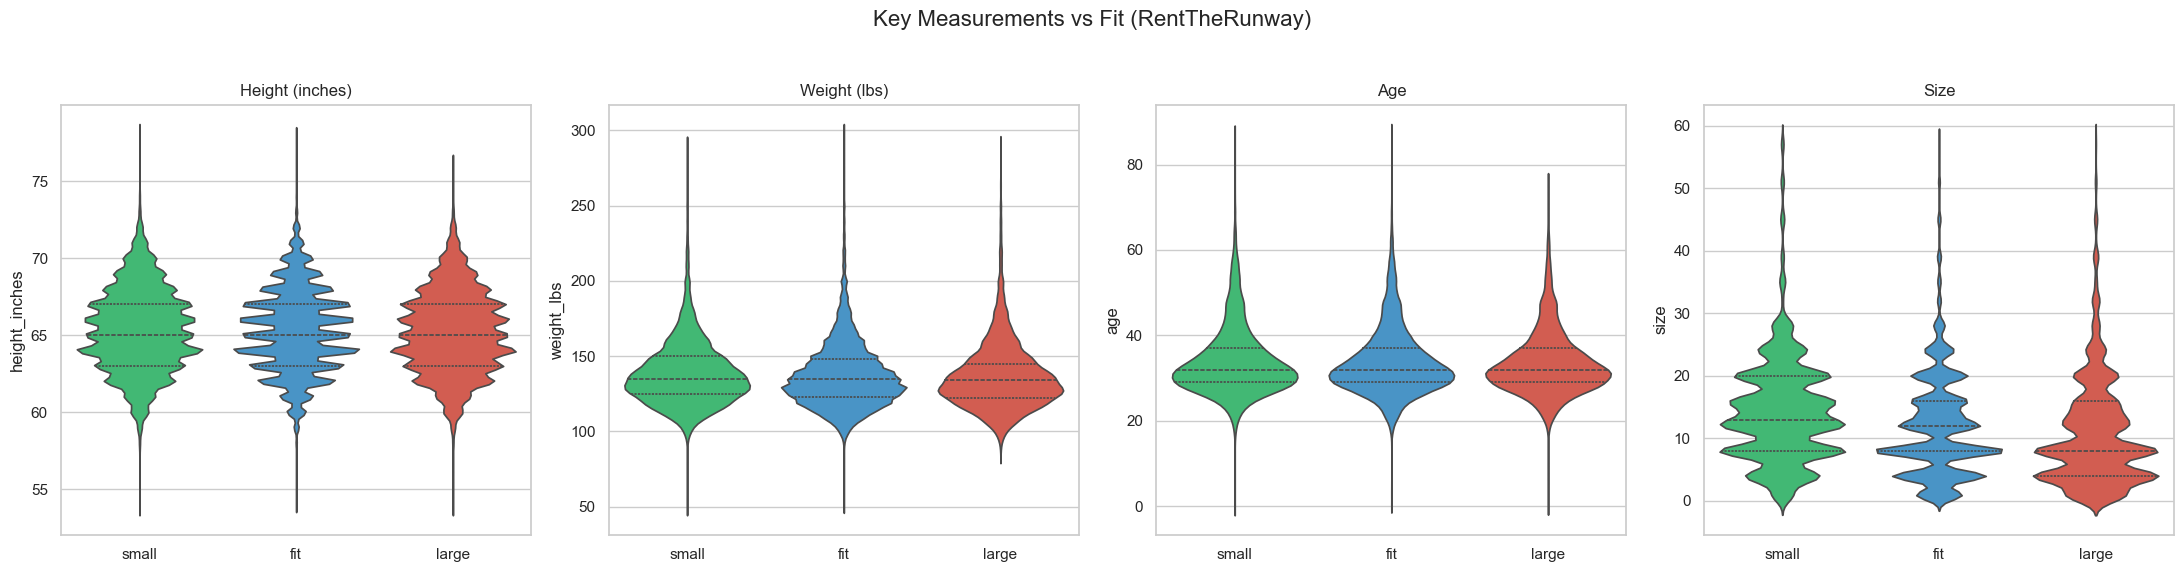

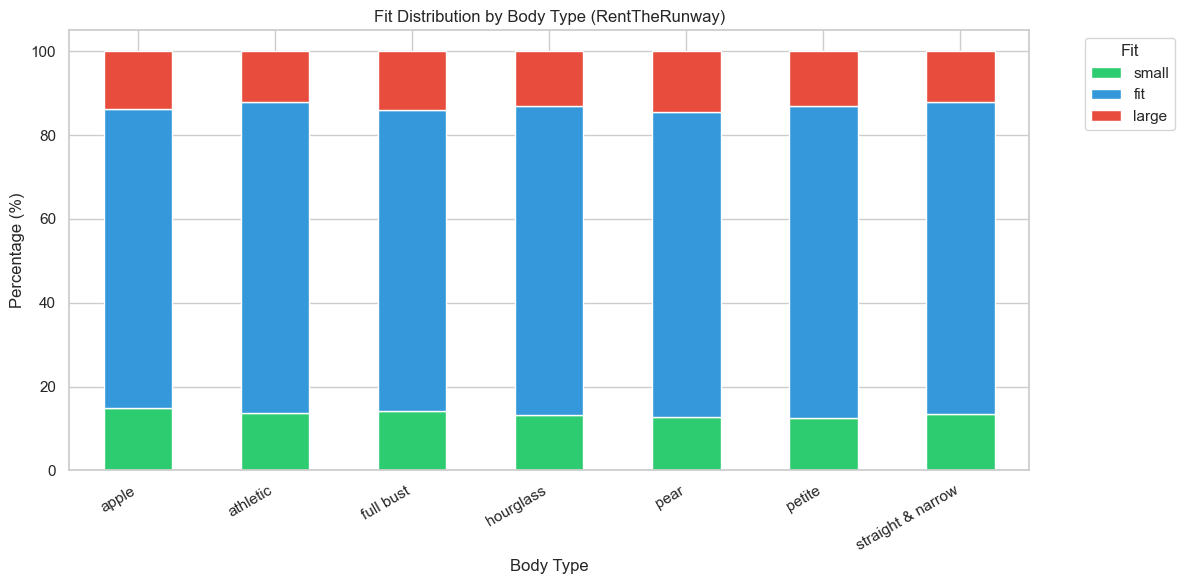

In [12]:
# Violin plots of key measurements vs fit (RTR)
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Key Measurements vs Fit (RentTheRunway)', fontsize=16)

fit_order = ['small', 'fit', 'large']
palette = {'small': '#2ecc71', 'fit': '#3498db', 'large': '#e74c3c'}

for ax, col, title in zip(axes,
                          ['height_inches', 'weight_lbs', 'age', 'size'],
                          ['Height (inches)', 'Weight (lbs)', 'Age', 'Size']):
    sns.violinplot(data=rtr_df, x='fit', y=col, order=fit_order, palette=palette,
                   inner='quartile', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Fit vs Body Type
body_fit = pd.crosstab(rtr_df['body type'], rtr_df['fit'], normalize='index') * 100
body_fit = body_fit[['small', 'fit', 'large']]
body_fit.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Fit Distribution by Body Type (RentTheRunway)')
plt.ylabel('Percentage (%)')
plt.xlabel('Body Type')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Fit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Correlation Heatmaps

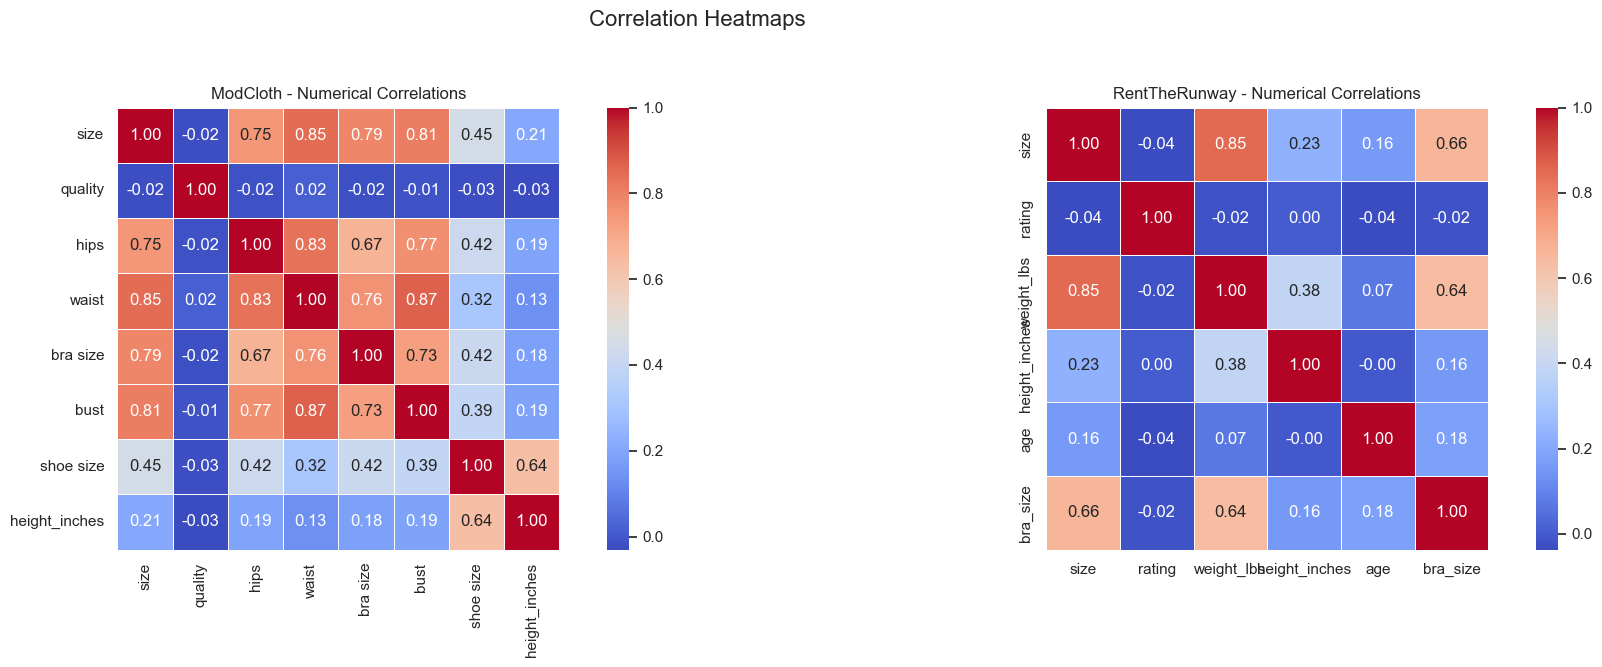

In [13]:
# Correlation heatmaps for both datasets
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Correlation Heatmaps', fontsize=16)

# ModCloth correlations
mc_numeric = modcloth_df[['size', 'quality', 'hips', 'waist', 'bra size', 'bust', 'shoe size', 'height_inches']].copy()
mc_corr = mc_numeric.corr()
sns.heatmap(mc_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], linewidths=0.5, square=True)
axes[0].set_title('ModCloth - Numerical Correlations')

# RTR correlations
rtr_numeric = rtr_df[['size', 'rating', 'weight_lbs', 'height_inches', 'age', 'bra_size']].copy()
rtr_corr = rtr_numeric.corr()
sns.heatmap(rtr_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], linewidths=0.5, square=True)
axes[1].set_title('RentTheRunway - Numerical Correlations')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 5. Time Series Analysis (RentTheRunway)

Let's analyze how rentals and fit feedback have changed over time.

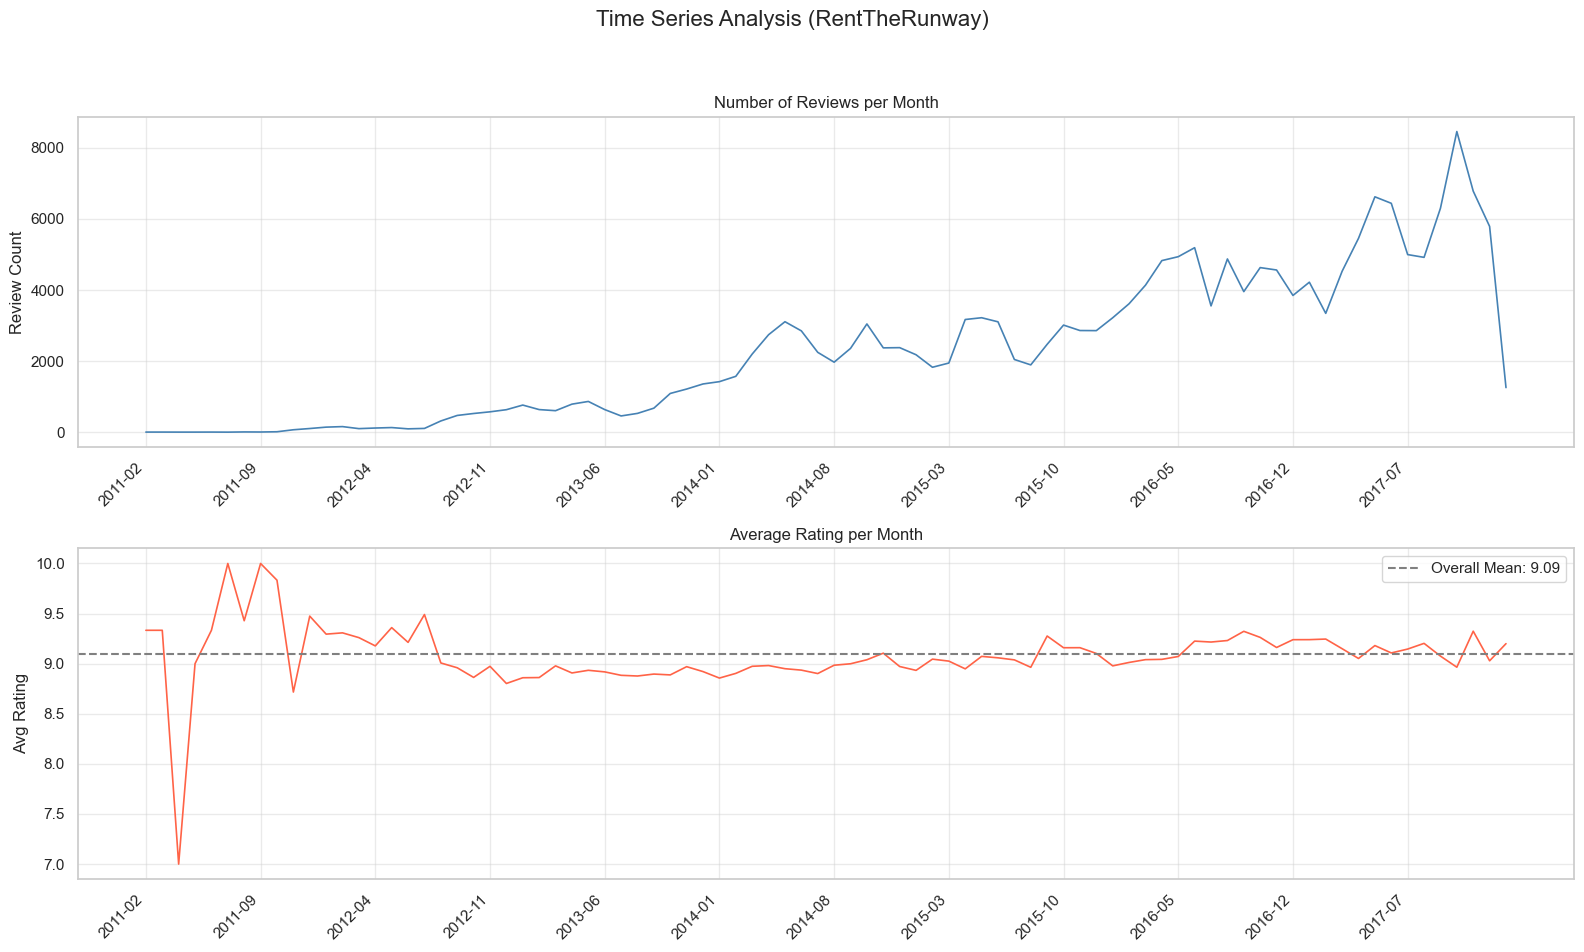

In [14]:
# Reviews over time
rtr_time = rtr_df.dropna(subset=['review_date']).copy()
rtr_time['year_month'] = rtr_time['review_date'].dt.to_period('M')

# Reviews per month
monthly_reviews = rtr_time.groupby('year_month').size().reset_index(name='count')
monthly_reviews['year_month'] = monthly_reviews['year_month'].astype(str)
# Keep only months with data (filter to reasonable date range)
monthly_reviews = monthly_reviews[monthly_reviews['year_month'] >= '2011-01']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Time Series Analysis (RentTheRunway)', fontsize=16)

# Reviews per month
axes[0].plot(monthly_reviews['year_month'], monthly_reviews['count'], color='steelblue', linewidth=1.2)
axes[0].set_title('Number of Reviews per Month')
axes[0].set_ylabel('Review Count')
axes[0].set_xlabel('')
tick_step = max(1, len(monthly_reviews) // 12)
axes[0].set_xticks(range(0, len(monthly_reviews), tick_step))
axes[0].set_xticklabels(monthly_reviews['year_month'].iloc[::tick_step], rotation=45, ha='right')
axes[0].grid(True, alpha=0.4)

# Average rating per month
monthly_rating = rtr_time.groupby('year_month')['rating'].mean().reset_index(name='avg_rating')
monthly_rating['year_month'] = monthly_rating['year_month'].astype(str)
monthly_rating = monthly_rating[monthly_rating['year_month'] >= '2011-01']

axes[1].plot(monthly_rating['year_month'], monthly_rating['avg_rating'], color='tomato', linewidth=1.2)
axes[1].axhline(y=rtr_df['rating'].mean(), color='gray', linestyle='--', label=f"Overall Mean: {rtr_df['rating'].mean():.2f}")
axes[1].set_title('Average Rating per Month')
axes[1].set_ylabel('Avg Rating')
axes[1].set_xlabel('')
axes[1].set_xticks(range(0, len(monthly_rating), tick_step))
axes[1].set_xticklabels(monthly_rating['year_month'].iloc[::tick_step], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 6. Rating and Review Length Analysis (RentTheRunway)

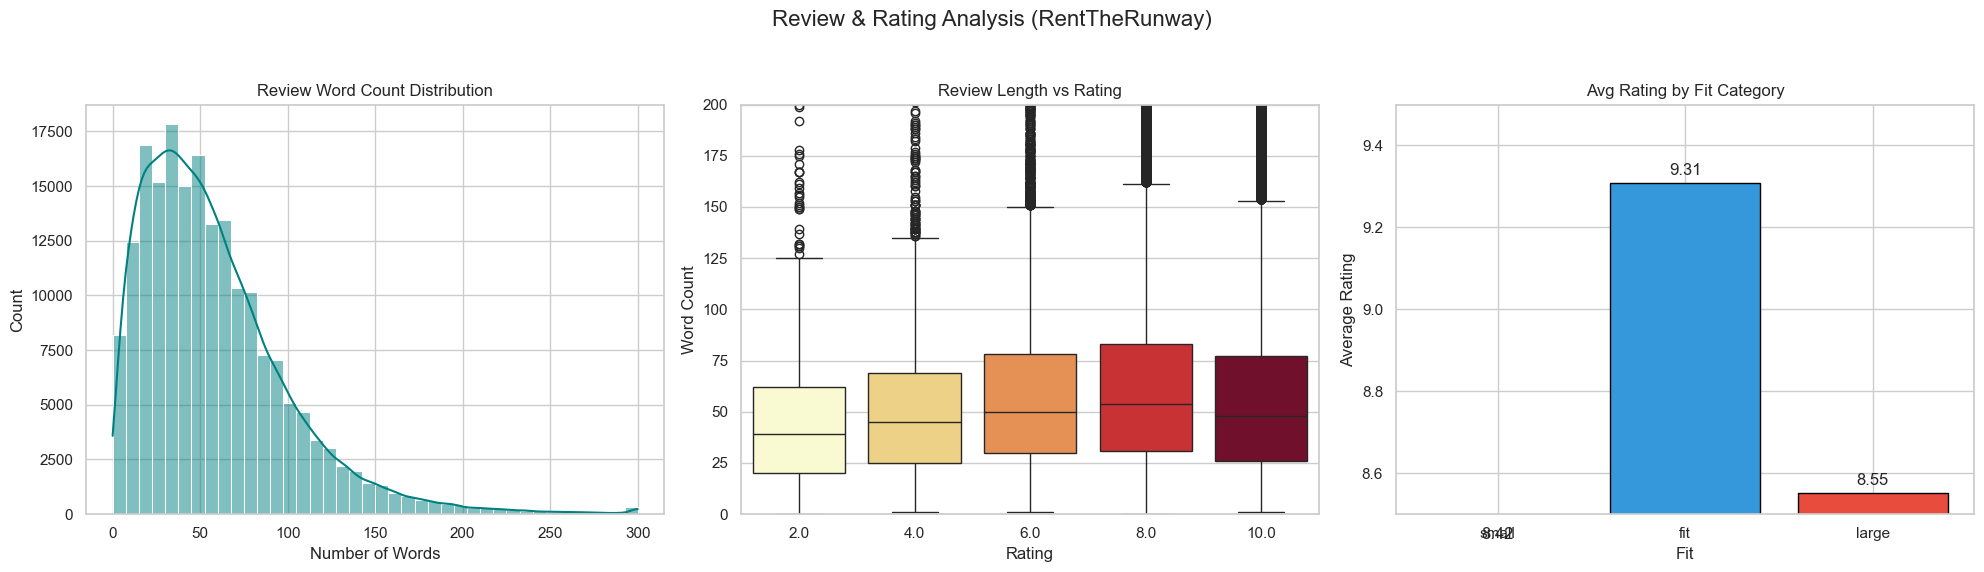

In [15]:
# Review length analysis
rtr_df['review_length'] = rtr_df['review_text'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Review & Rating Analysis (RentTheRunway)', fontsize=16)

# Distribution of review length
sns.histplot(rtr_df['review_length'].dropna().clip(upper=300), bins=40, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Review Word Count Distribution')
axes[0].set_xlabel('Number of Words')

# Review length vs Rating
sns.boxplot(data=rtr_df, x='rating', y='review_length', ax=axes[1], hue='rating', legend=False, palette='YlOrRd')
axes[1].set_title('Review Length vs Rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Word Count')
axes[1].set_ylim(0, 200)

# Rating vs Fit
rating_fit = rtr_df.groupby('fit')['rating'].mean().reindex(['small', 'fit', 'large'])
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = axes[2].bar(rating_fit.index, rating_fit.values, color=colors, edgecolor='black')
axes[2].set_title('Avg Rating by Fit Category')
axes[2].set_xlabel('Fit')
axes[2].set_ylabel('Average Rating')
axes[2].set_ylim(8.5, 9.5)
for bar, v in zip(bars, rating_fit.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}', ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 7. Cup Size Analysis (Both Datasets)

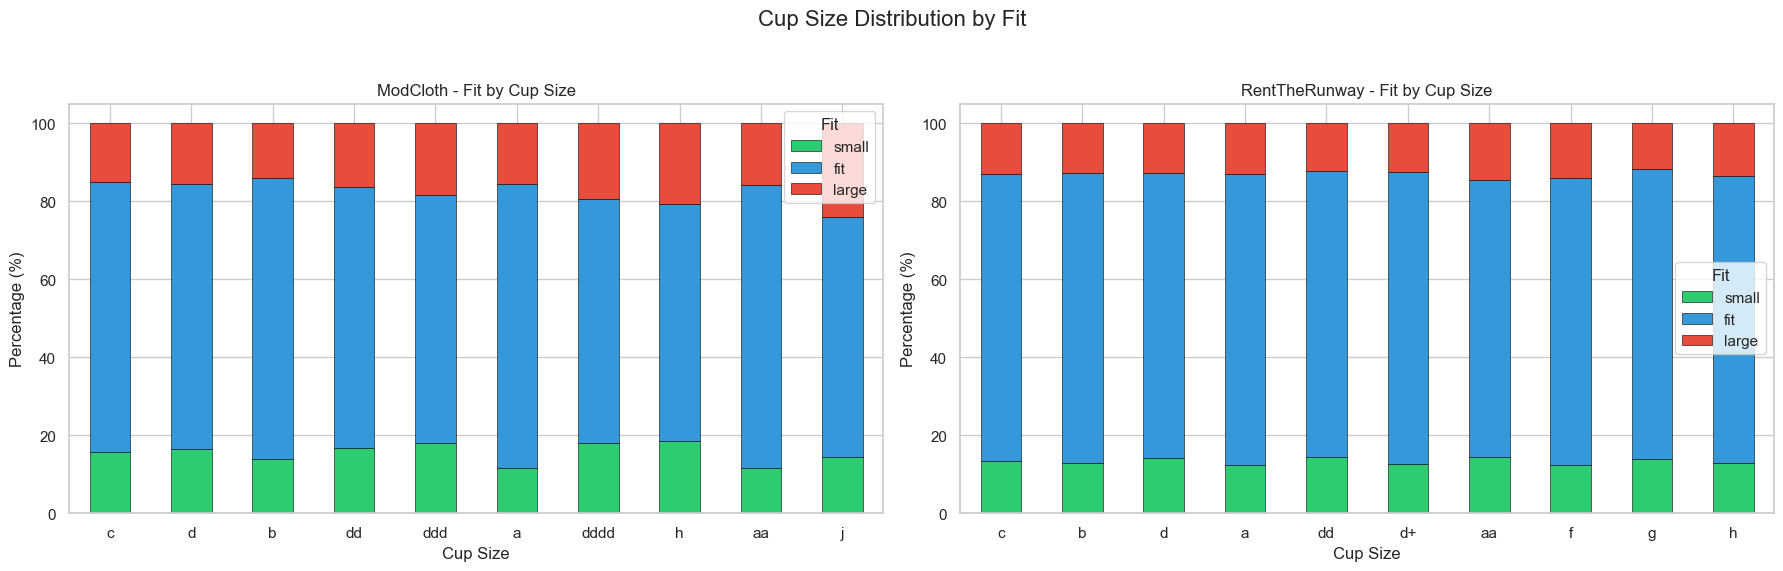

In [16]:
# Cup size analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Cup Size Distribution by Fit', fontsize=16)

# ModCloth - normalize cup size labels that have slashes (take first part: e.g., "dd/e" -> "dd")
mc_cup = modcloth_df.copy()
mc_cup['cup_size_clean'] = mc_cup['cup size'].str.split('/').str[0].str.lower().str.strip()
cup_order_mc = mc_cup['cup_size_clean'].value_counts().index[:10].tolist()
mc_cup_fit = pd.crosstab(mc_cup['cup_size_clean'], mc_cup['fit'], normalize='index') * 100
mc_cup_fit = mc_cup_fit.reindex(cup_order_mc)
mc_cup_fit[['small', 'fit', 'large']].plot(kind='bar', stacked=True, ax=axes[0],
                                            color=['#2ecc71', '#3498db', '#e74c3c'],
                                            edgecolor='black', linewidth=0.4)
axes[0].set_title('ModCloth - Fit by Cup Size')
axes[0].set_xlabel('Cup Size')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Fit')

# RTR cup size
cup_order_rtr = rtr_df['cup_size'].value_counts().index[:10].tolist()
rtr_cup_fit = pd.crosstab(rtr_df['cup_size'], rtr_df['fit'], normalize='index') * 100
rtr_cup_fit = rtr_cup_fit.reindex(cup_order_rtr)
rtr_cup_fit[['small', 'fit', 'large']].plot(kind='bar', stacked=True, ax=axes[1],
                                             color=['#2ecc71', '#3498db', '#e74c3c'],
                                             edgecolor='black', linewidth=0.4)
axes[1].set_title('RentTheRunway - Fit by Cup Size')
axes[1].set_xlabel('Cup Size')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Fit')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 8. Summary Statistics

In [17]:
print("=" * 60)
print("MODCLOTH DATASET - SUMMARY STATISTICS")
print("=" * 60)
print(modcloth_df[['size', 'quality', 'hips', 'waist', 'bra size', 'bust', 'height_inches']].describe().round(2))

print("\n")
print("=" * 60)
print("RENTTHERUNWAY DATASET - SUMMARY STATISTICS")
print("=" * 60)
print(rtr_df[['size', 'rating', 'weight_lbs', 'height_inches', 'age', 'bra_size']].describe().round(2))

print("\nModCloth - Fit value counts:")
print(modcloth_df['fit'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\nRentTheRunway - Fit value counts:")
print(rtr_df['fit'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

MODCLOTH DATASET - SUMMARY STATISTICS
           size   quality      hips    waist  bra size      bust  \
count  82790.00  82722.00  56064.00  2882.00  76772.00  11854.00   
mean      12.66      3.95     40.36    31.32     35.97     37.50   
std        8.27      0.99      5.83     5.30      3.22      4.64   
min        0.00      1.00     30.00    20.00     28.00     20.00   
25%        8.00      3.00     36.00    28.00     34.00     34.00   
50%       12.00      4.00     39.00    30.00     36.00     36.00   
75%       15.00      5.00     43.00    34.00     38.00     40.00   
max       38.00      5.00     60.00    50.00     48.00     59.00   

       height_inches  
count       81683.00  
mean           65.15  
std             2.85  
min            36.00  
25%            63.00  
50%            65.00  
75%            67.00  
max            95.00  


RENTTHERUNWAY DATASET - SUMMARY STATISTICS
            size     rating  weight_lbs  height_inches        age   bra_size
count  192544.00  19

## 9. Key Findings and Insights

### ModCloth Dataset

**Data Quality:**
- **Heavy sparsity** in body measurement columns: `waist` (96.5% missing), `bust` (85.7% missing), `shoe width` (77.5% missing), and `shoe size` (66.3% missing). Only `hips` (32.3% missing), `bra size` (7.3%), and `cup size` (7.6%) are reasonably well populated.
- The `category` field mostly has a `"new"` label (~26%), suggesting this attribute was not consistently filled in.
- Height is skewed by a few extreme outliers (e.g., values >90 inches) that likely reflect data entry errors.

**Distributions:**
- The **Size** distribution is multimodal (peaks around sizes 7, 9, 13), reflecting standard clothing sizes.
- **Height** follows a near-normal distribution centered around 65 inches (~5'5"), which is close to the average US female height.
- **Bra size** shows peaks at 34, 36, and 38, aligning with common underband sizes.
- **Quality ratings** are strongly left-skewed, with the majority of ratings being 4 or 5, indicating a positively biased review culture.

**Fit Analysis:**
- **~68.6%** of reviews report a `fit`, ~15.7% report `small`, and ~15.8% report `large`, showing a slight symmetric bias in misfits.
- Height, size, and bra size distributions are **nearly identical** across the three `fit` categories, suggesting these individual measurements alone are weakly predictive of fit — fit is likely a complex interaction of multiple body measurements and garment design.
- **Wedding items** have the lowest `small` rate (~5%), while `bottoms` and `sale` categories have the highest `small` rates, suggesting size calibration varies by garment type.

**Correlations:**
- Very strong positive correlations exist between body measurement columns: `size` ↔ `waist` (0.85), `size` ↔ `bust` (0.81), and `hips` ↔ `bust` (0.77), reflecting that larger garment sizes correlate with larger body measurements.
- `quality` has almost **zero correlation** with any body measurement, confirming it is an independent user satisfaction score.
- `shoe_size` correlates strongly with `height_inches` (0.64), which is expected biologically.

---

### RentTheRunway Dataset

**Data Quality:**
- Much better data completeness overall — most columns have <16% missing values.
- `weight` (15.6% missing), `bust size` (9.6%), `body type` (7.6%), and `cup_size` (10.9%) are the primary sparse columns.
- One entry had an `age` of 116, which was removed as an outlier. After filtering, age ranges from 0–88.

**Distributions:**
- **Height** is approximately normally distributed, centered around 65 inches (~5'5").
- **Weight** is right-skewed with a median of ~135 lbs and a long tail up to 300 lbs.
- **Age** is right-skewed, with the majority of users in their late 20s to mid-30s, reflecting the platform's typical demographic.
- **Ratings** are heavily concentrated at 10 (the maximum), creating a pronounced ceiling effect — over 60% of all ratings are a perfect 10.
- **Size** is multimodal (peaks at 4, 8, 10, 14), reflecting the typical even-number women's dress sizing system.
- The platform is dominated by `hourglass` and `athletic` body types among users.

**Fit Analysis:**
- A strong **73.8%** of rentals report `fit`, ~13.4% report `small`, and ~12.8% report `large`.
- Fit percentages are **remarkably consistent across body types** (all hover around 85–88% fit), indicating the platform's sizing or recommendation system performs well uniformly.
- `apple` body types are slightly more likely to report items as `small` (~15%) vs. `petite` types (~12%), suggesting systematic fit challenges for that shape.
- Customers who reported a `fit` item gave an average rating of **9.31**, vs. **8.55 for `large`** and **8.47 for `small`**, confirming that a proper fit strongly correlates with higher satisfaction.

**Time Series:**
- Review volume grew steadily from ~2011 to a peak in late 2017, consistent with the platform's growth trajectory.
- Average monthly ratings stabilized around 9.0 after an early volatile period (2011–early 2012), likely reflecting a larger and more diverse user base stabilizing expectations.

**Review Length:**
- Review length is right-skewed (median ~45–50 words), with most users writing short reviews.
- Higher-rated reviews (8–10) tend to be slightly longer than low-rated ones (2–4), suggesting satisfied customers engage more elaborately with feedback.

---

### Cross-Dataset Observations
- Both datasets show a similar pattern: **~65–75% of reviews report a proper fit**, with the remaining split roughly equally between `small` and `large`.
- Body measurements (height, bra size, weight) show **minimal differentiation across fit categories** in isolation — suggesting the prediction problem requires multi-feature modeling.
- The strong correlation between `size` and body measurements in ModCloth suggests that **size alone is a decent proxy for body shape** when detailed measurements are unavailable.

## 10. Recommended Topic Pairing from EDA

Based on the EDA patterns, the best pair is:

1. **Bayesian Modeling**
   - Class outcomes are probabilistic (`small`, `fit`, `large`) and imbalanced (~65–75% `fit`).
   - Priors + posterior uncertainty are useful for stable inference on minority classes.

2. **AR/MA Time Series (on RTR)**
   - RTR has a strong `review_date` signal and clear monthly trends in volume/ratings.
   - AR/MA models fit naturally to monthly fit-rate or rating trajectories.

Why not collaborative filtering as the second topic here?
- EDA and current cleaned modeling tables are feature-focused and do not currently preserve user-item IDs needed for classic CF.

In [ ]:
# Build a monthly RTR fit-rate series to support AR/MA modeling later
rtr_ts_fit = rtr_df.dropna(subset=['review_date', 'fit']).copy()
rtr_ts_fit['year_month'] = rtr_ts_fit['review_date'].dt.to_period('M').dt.to_timestamp()

monthly_fit_rate = (
    rtr_ts_fit.assign(is_fit=(rtr_ts_fit['fit'] == 'fit').astype(int))
    .groupby('year_month')['is_fit']
    .mean()
    .rename('fit_rate')
    .sort_index()
)

monthly_fit_rate_df = monthly_fit_rate.reset_index()
print('Monthly fit-rate rows:', len(monthly_fit_rate_df))
monthly_fit_rate_df.head()